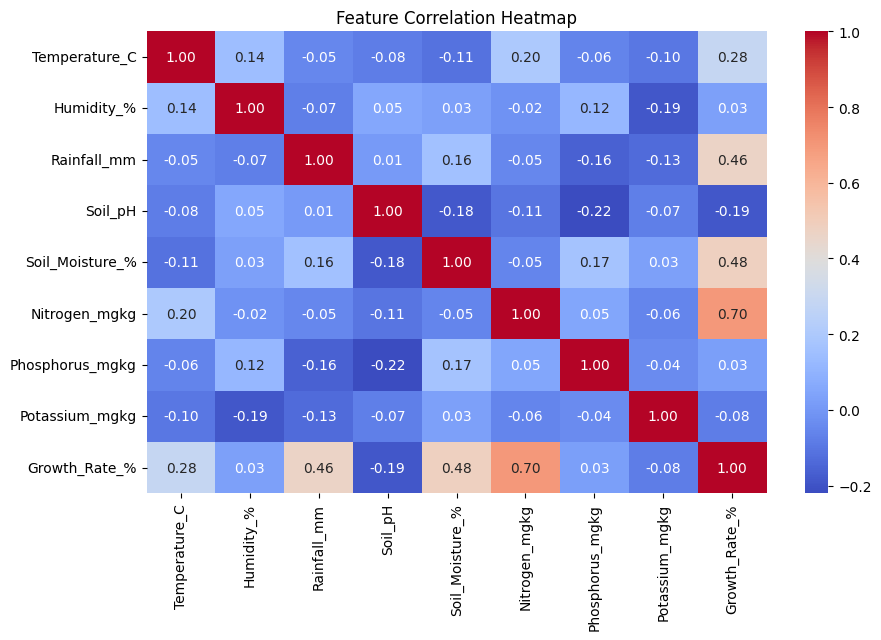

Model Performance:
MAE: 2.35, MSE: 9.02, R² Score: 0.83
✅ Model saved as crop_growth_model.pkl


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


np.random.seed(42)
field_data = {
    "Temperature_C": np.random.randint(18, 35, 100),
    "Humidity_%": np.random.randint(40, 85, 100),
    "Rainfall_mm": np.random.randint(0, 120, 100),
    "Soil_pH": np.round(np.random.uniform(6.0, 7.5, 100), 1),
    "Soil_Moisture_%": np.random.randint(30, 80, 100),
    "Nitrogen_mgkg": np.random.randint(50, 150, 100),
    "Phosphorus_mgkg": np.random.randint(20, 100, 100),
    "Potassium_mgkg": np.random.randint(30, 180, 100),
}


field_data["Growth_Rate_%"] = [
    round(0.4 * t + 0.3 * sm + 0.2 * n + 0.1 * r + np.random.uniform(-2, 2), 1)
    for t, sm, n, r in zip(field_data["Temperature_C"], field_data["Soil_Moisture_%"], field_data["Nitrogen_mgkg"], field_data["Rainfall_mm"])
]


df = pd.DataFrame(field_dataBA""" """ """ """ """ A """ """ """ """ """)


features = ['Temperature_C', 'Humidity_%', 'Rainfall_mm', 'Soil_pH', 
            'Soil_Moisture_%', 'Nitrogen_mgkg', 'Phosphorus_mgkg', 'Potassium_mgkg']
target = 'Growth_Rate_%'


plt.figure(figsize=(10, 6))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])


X_train, X_test, y_train, y_test = train_test_split(df_scaled[features], df_scaled[target], test_size=0.2, random_state=42)


model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:\nMAE: {mae:.2f}, MSE: {mse:.2f}, R² Score: {r2:.2f}")


with open("crop_growth_model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

print("✅ Model saved as crop_growth_model.pkl")
